# Generalized soft $c$-transforms for $\phi$-regularized OT

This notebook generates `fig:sinkhorn-phi-soft-c-transforms`.  For the density-ratio regularized problem
$$
    \min_{\pi\in\Pi(\alpha,\beta)} \int c\,d\pi + \varepsilon D_\phi(\pi|\alpha\otimes\beta),
$$
the dual block update is no longer necessarily a log-sum-exp transform.  For a fixed potential $g$ on $Y$, the source update is the scalar maximizer
$$
    g^{\bar c,\varepsilon,\phi}(x)
    = \arg\min_{u\in\mathbb R}
    \left\{
        \varepsilon \int_Y
        \phi^{*,\geq0}\!\left(\frac{u+g(y)-c(x,y)}{\varepsilon}\right)d\beta(y)-u
    \right\}.
$$
Equivalently, if $\phi$ is differentiable, $u=g^{\bar c,\varepsilon,\phi}(x)$ is characterized by
$$
    \int_Y (\phi^{*,\geq0})'\!\left(\frac{u+g(y)-c(x,y)}{\varepsilon}\right)d\beta(y)=1.
$$
The figure uses the bilinear cost $c(x,y)=-xy$ and displays the double transform $(f^{c,\varepsilon,\phi})^{\bar c,\varepsilon,\phi}$ of an oscillating non-concave input.  Additive constants are removed by centering, because Sinkhorn potentials are defined only up to gauge.


In [1]:
from pathlib import Path
import io
import os
import shutil
import sys
from contextlib import redirect_stderr

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image as DisplayImage
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
elif not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent

FIGROOT = ROOT / "notebooks-figures"
sys.path.insert(0, str(FIGROOT.resolve()))

from figure_style import (
    BLUE,
    GRAY,
    LIGHT_GRAY,
    RED,
    VIOLET,
    box_axes,
    figure_dir,
    interp_color,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "sinkhorn-phi-soft-c-transforms"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
THUMB_OUT = FIGROOT / "thumbnails"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_OUT.mkdir(parents=True, exist_ok=True)


## One-dimensional bilinear model

The displayed grid is the source space.  The intermediate target grid is wider, so that the hard double transform for $c(x,y)=-xy$ accurately approximates the unconstrained least concave majorant.  The initial potential is non-concave but not excessively oscillatory, making the zero-temperature envelope visible.  The colored curves use increasing regularization strengths; the numerical scale of $\varepsilon$ is chosen separately for each generator because KL, Burg, and quadratic density-ratio penalties have different stiffness.

In [2]:
N = 620
M = 860
x = np.linspace(-2.8, 2.8, N)
y = np.linspace(-6.5, 6.5, M)
alpha_weights = np.ones_like(x) / len(x)
beta_weights = np.ones_like(y) / len(y)
C_xy = -np.outer(x, y)

# A deliberately non-concave input.  The moderate oscillations make the hard
# concave envelope readable while still leaving visible contact/non-contact
# regions for the double transform.
f_input = (
    -0.14 * x**2
    + 0.34 * np.sin(2.8 * x)
    + 0.16 * np.sin(5.8 * x + 0.35)
    + 0.07 * np.cos(9.0 * x - 0.2)
)
f_input -= np.average(f_input, weights=alpha_weights)

# The zero-temperature limit is reached at different numerical epsilon scales
# for different density-ratio penalties.  In particular, the quadratic law
# rho(s)=(1+s)_+ has a much slower visible approach on a finite grid.
eps_by_kind = {
    "kl": [0.001, 0.012, 0.05, 0.20],
    "burg": [0.001, 0.03, 0.15, 0.65],
    "quadratic": [1.0e-5, 1.0e-4, 1.0e-3, 1.0e-2],
}
eps_colors = [interp_color(t) for t in np.linspace(0.0, 1.0, 4)]

## Generalized scalar transforms

For KL, Burg, and quadratic density-ratio penalties, the derivative of the positive conjugate is respectively
$$
    (\phi^{*,\geq0})'(s)=e^s,
    \qquad
    (\phi^{*,\geq0})'(s)=(1-s)^{-1},
    \qquad
    (\phi^{*,\geq0})'(s)=(1+s)_+.
$$
The transform is computed by solving the corresponding monotone scalar equation at each grid location.  The KL case uses the closed-form stabilized log-sum-exp formula.


In [3]:
def center_potential(values, weights):
    return values - np.average(values, weights=weights)


def hard_transform(h, cost_matrix):
    return np.min(cost_matrix - h[:, None], axis=0)


def generalized_soft_transform(h, cost_matrix, source_weights, epsilon, kind):
    """Return the block maximizer for one phi-soft c-transform.

    ``h`` lives on the source grid of ``cost_matrix`` and the output lives on
    the target grid.  The update solves
        sum_i w_i rho((u + h_i - C_ij)/epsilon) = 1
    where rho=(phi*)' is the density law associated with the regularizer.
    """
    if epsilon == 0:
        return hard_transform(h, cost_matrix)

    scores_without_u = h[:, None] - cost_matrix

    if kind == "kl":
        z = scores_without_u / epsilon
        zmax = z.max(axis=0)
        log_integral = zmax + np.log(
            np.sum(source_weights[:, None] * np.exp(z - zmax[None, :]), axis=0)
        )
        return -epsilon * log_integral

    out = np.empty(cost_matrix.shape[1])
    for j in range(cost_matrix.shape[1]):
        z = scores_without_u[:, j]

        if kind == "burg":
            # Domain condition: (u+z)/epsilon < 1 for every active point.
            hi = float(np.min(epsilon - z) - 1e-12)
            lo = hi - 10.0

            def mass(u):
                s = (u + z) / epsilon
                return np.sum(source_weights / np.maximum(1.0 - s, 1e-14))

            while mass(lo) > 1.0:
                lo -= 10.0

        elif kind == "quadratic":
            lo = float(-np.max(z) - epsilon - 8.0)
            hi = float(-np.min(z) + epsilon + 8.0)

            def mass(u):
                s = (u + z) / epsilon
                return np.sum(source_weights * np.maximum(0.0, 1.0 + s))

            while mass(lo) > 1.0:
                lo -= 8.0
            while mass(hi) < 1.0:
                hi += 8.0

        else:
            raise ValueError(f"Unknown regularizer kind: {kind}")

        for _ in range(54):
            mid = 0.5 * (lo + hi)
            if mass(mid) > 1.0:
                hi = mid
            else:
                lo = mid
        out[j] = 0.5 * (lo + hi)

    return out


def double_transform(kind, epsilon):
    first = generalized_soft_transform(f_input, C_xy, alpha_weights, epsilon, kind)
    second = generalized_soft_transform(first, C_xy.T, beta_weights, epsilon, kind)
    return center_potential(second, alpha_weights)


hard_double = center_potential(double_transform("kl", 0), alpha_weights)
curves = {
    kind: {epsilon: double_transform(kind, epsilon) for epsilon in epsilons}
    for kind, epsilons in eps_by_kind.items()
}

for kind in curves:
    max_concavity_violation = max(
        np.max(np.diff(np.diff(values)) / (x[1] - x[0]) ** 2)
        for values in curves[kind].values()
    )
    print(f"{kind:>9s}: max discrete convexity residual = {max_concavity_violation:+.3e}")


       kl: max discrete convexity residual = -1.828e-06
     burg: max discrete convexity residual = -2.128e-09
quadratic: max discrete convexity residual = +5.697e-11


## Rendering

Each PDF panel is title-free.  LaTeX supplies the family labels and the caption explains the color encoding.  The dashed curve is the non-concave input, the dark curve is the hard double transform, and red-to-blue curves correspond to increasing regularization strengths.  The red curve uses a near-zero value and should therefore sit on the hard concave envelope.

In [4]:
ymin = min(f_input.min(), hard_double.min(), *(v.min() for family in curves.values() for v in family.values())) - 0.08
ymax = max(f_input.max(), hard_double.max(), *(v.max() for family in curves.values() for v in family.values())) + 0.08

panel_names = {
    "kl": "kl",
    "burg": "burg",
    "quadratic": "quadratic",
}


INPUT_COLOR = "#c9bda9"
HARD_COLOR = "#2b2b2b"


def draw_panel(ax, kind):
    ax.plot(x, f_input, color=INPUT_COLOR, lw=1.10, ls=(0, (3.4, 2.1)), alpha=0.96, zorder=1)
    ax.plot(x, hard_double, color=HARD_COLOR, lw=1.28, alpha=0.92, zorder=2)
    for color, epsilon in zip(eps_colors, eps_by_kind[kind]):
        ax.plot(x, curves[kind][epsilon], color=color, lw=1.34, alpha=0.98, zorder=3)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([])
    ax.set_xlabel(r"$x$")
    box_axes(ax)


for kind, name in panel_names.items():
    fig, ax = plt.subplots(figsize=(2.56, 1.86))
    draw_panel(ax, kind)
    with redirect_stderr(io.StringIO()):
        save_pdf(fig, OUT / f"{name}.pdf", pad_inches=0.038)
    plt.close(fig)
    shutil.copyfile(OUT / f"{name}.pdf", ARXIV_OUT / f"{NAME}--{name}.pdf")

fig, axes = plt.subplots(1, 3, figsize=(7.52, 1.96), sharey=True)
for ax, kind in zip(axes, ["kl", "burg", "quadratic"]):
    draw_panel(ax, kind)
fig.subplots_adjust(left=0.006, right=0.997, bottom=0.18, top=0.985, wspace=0.072)
fig.savefig(THUMB_OUT / f"{NAME}.png", dpi=220, bbox_inches="tight", pad_inches=0.030)
plt.close(fig)

print(f"Wrote {OUT}")
print(f"Wrote {THUMB_OUT / (NAME + '.png')}")


Wrote /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/sinkhorn-phi-soft-c-transforms
Wrote /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/sinkhorn-phi-soft-c-transforms.png


## Gallery preview

The preview below is generated from the same code as the PDF panels.


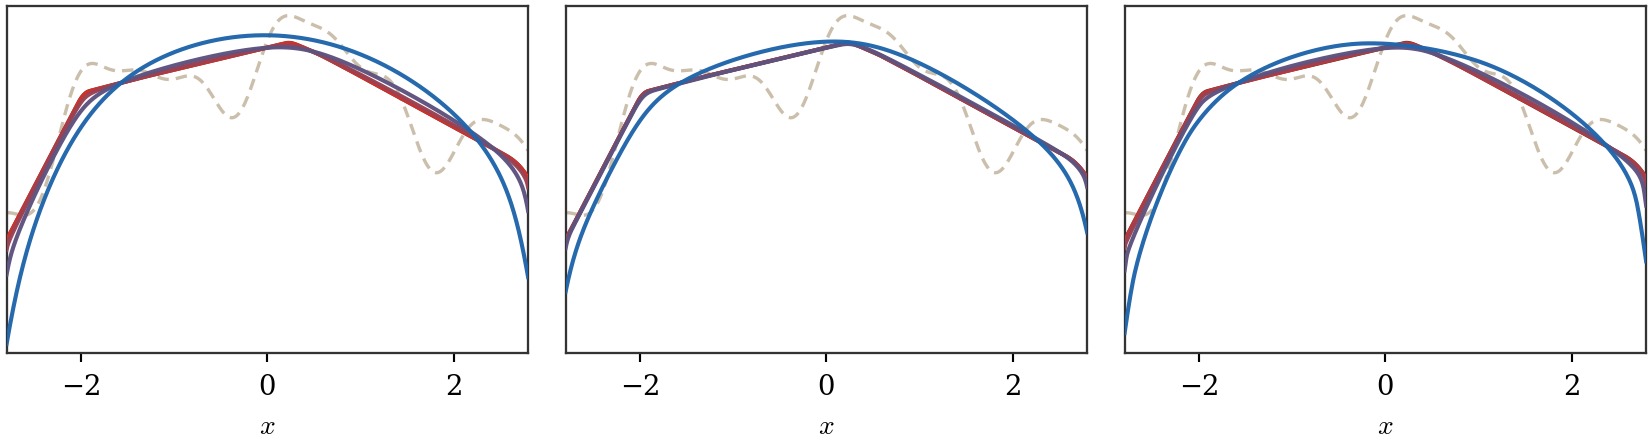

In [5]:
display(DisplayImage(filename=str(THUMB_OUT / f"{NAME}.png"), width=760))
